# EDA for ADKG and MDKG

## Imports

In [1]:
import json
from collections import Counter
import matplotlib.pyplot as plt
from itertools import combinations
import os

## Helper Functions

In [2]:
def load_dataset(base_path, name):
    train = json.load(open(f"{base_path}/{name}/{name}_train.json"))
    dev   = json.load(open(f"{base_path}/{name}/{name}_dev.json"))
    test  = json.load(open(f"{base_path}/{name}/{name}_test.json"))
    return train + dev + test

In [3]:
def get_entity_distribution(data):
    return Counter(
        entity["type"]
        for example in data
        for entity in example["entities"]
    )

In [4]:
def get_relation_distribution(data):
    return Counter(
        relation["type"]
        for example in data
        for relation in example["relations"]
    )

In [5]:
def get_entity_density(data):
    return [len(example["entities"]) for example in data]

In [6]:
def get_relation_density(data):
    return [len(example["relations"]) for example in data]

In [7]:
def get_sentence_lengths(data):
    return [len(example["tokens"]) for example in data]

In [8]:
def plot_bar(counter, title):
    plt.figure()
    plt.bar(counter.keys(), counter.values())
    plt.xticks(rotation=70)
    plt.title(title)
    
    filename = title.lower().replace(" ", "_") + ".png"
    save_path = os.path.join("../images", filename)

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [9]:
def plot_hist(values, title, bins=20):
    plt.figure()
    plt.hist(values, bins=bins)
    plt.title(title)
    
    filename = title.lower().replace(" ", "_") + ".png"
    save_path = os.path.join("../images", filename)

    os.makedirs("../images", exist_ok=True)

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

## ADKG

In [10]:
adkg = load_dataset("../data/datasets", "adkg")
len(adkg)

8031

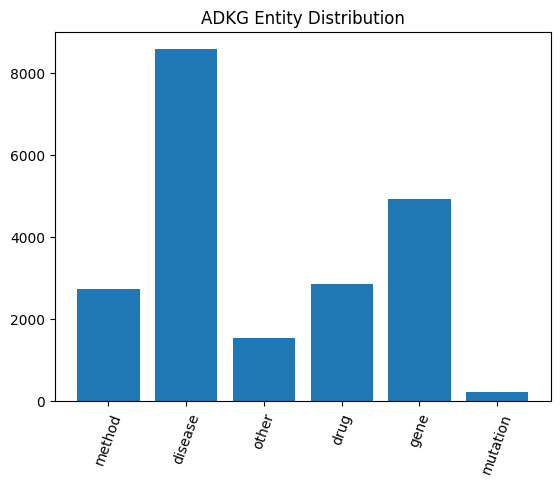

In [11]:
# entity distribution
plot_bar(get_entity_distribution(adkg), "ADKG Entity Distribution")

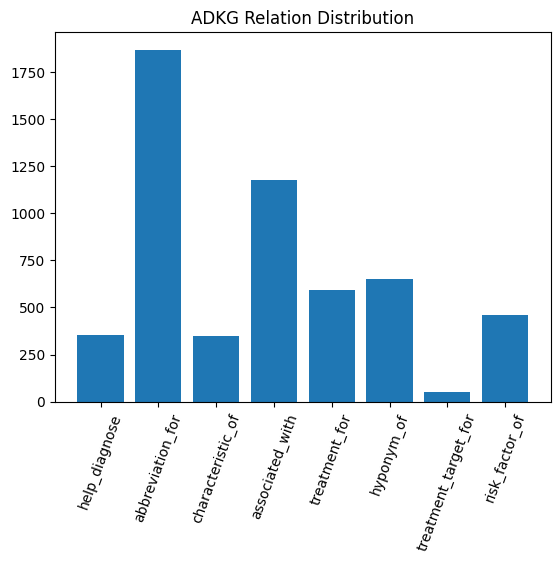

In [12]:
# relation distribution
plot_bar(get_relation_distribution(adkg), "ADKG Relation Distribution")

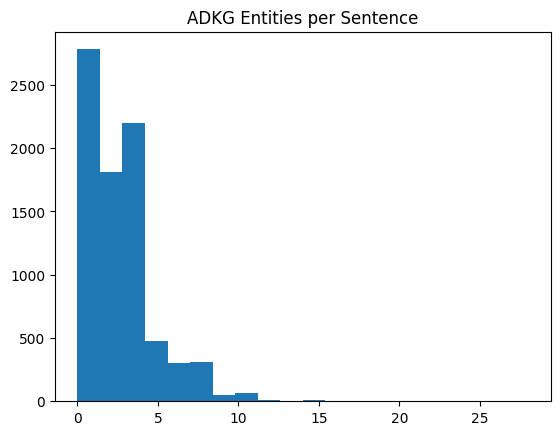

In [13]:
# entities per sentence
plot_hist(get_entity_density(adkg), "ADKG Entities per Sentence")

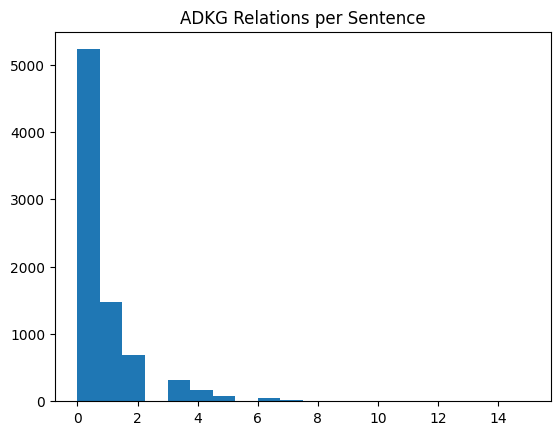

In [14]:
# relations per sentence
plot_hist(get_relation_density(adkg), "ADKG Relations per Sentence")

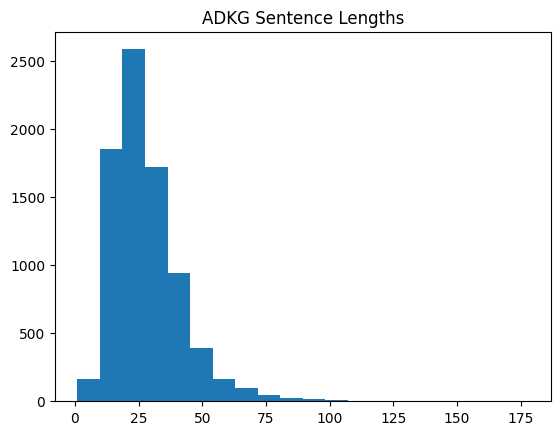

In [15]:
# sentence lengths
plot_hist(get_sentence_lengths(adkg), "ADKG Sentence Lengths")

## MDKG

In [20]:
mdkg = load_dataset("../data/datasets", "mdkg")
len(mdkg)

6678

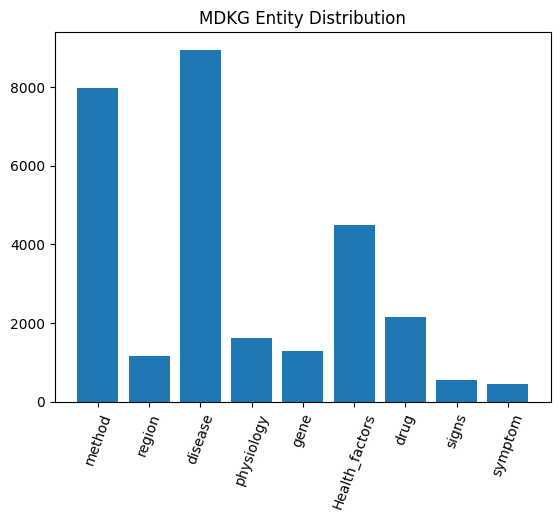

In [21]:
plot_bar(get_entity_distribution(mdkg), "MDKG Entity Distribution")

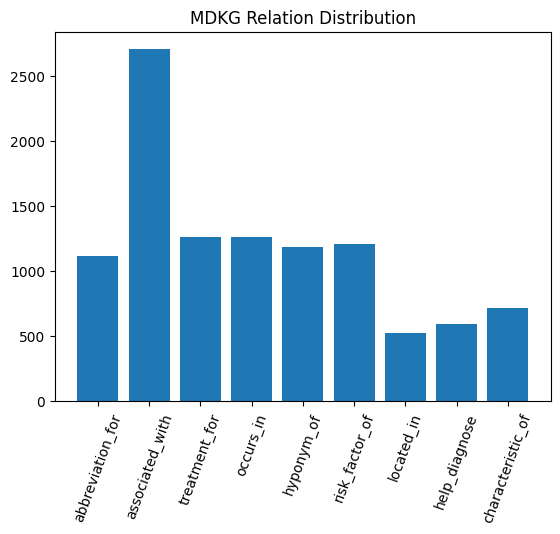

In [22]:
# relation distribution
plot_bar(get_relation_distribution(mdkg), "MDKG Relation Distribution")

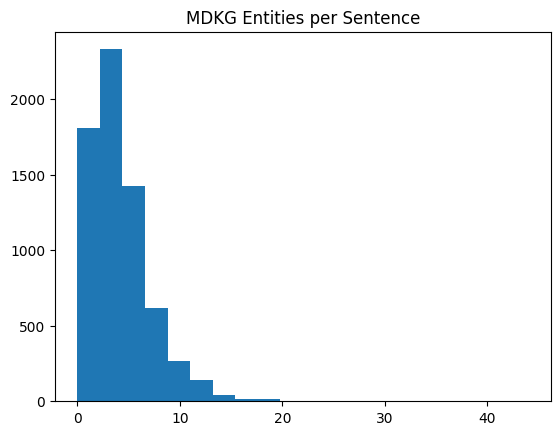

In [23]:
# entities per sentence
plot_hist(get_entity_density(mdkg), "MDKG Entities per Sentence")

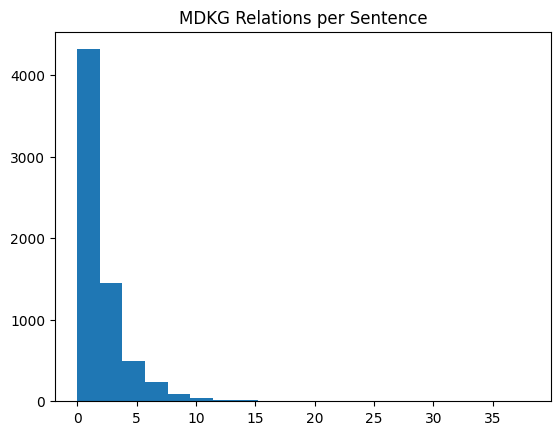

In [24]:
# relations per sentence
plot_hist(get_relation_density(mdkg), "MDKG Relations per Sentence")

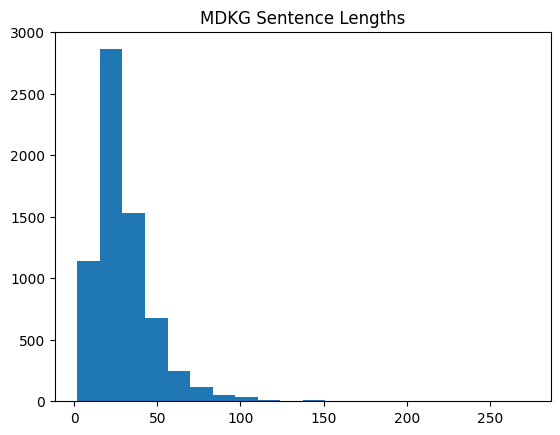

In [25]:
# sentence lengths
plot_hist(get_sentence_lengths(mdkg), "MDKG Sentence Lengths")